# Baseline Steel Thread — Isolating the Effect of Interventions on Item Warm-Up

This notebook builds a controlled experiment for measuring how a recommender's ability to
retrieve an item changes as that item accumulates its own interaction history — and it's
built specifically so that later interventions (content embeddings, improved content
embeddings, LLM-simulated interactions) can be added and compared on equal footing.

**The core experimental principle:** hold every source of variation fixed except the one
under study. User preferences are fit once, frozen, and reused identically everywhere in
this notebook — for the baseline pure-CF method here, and for every future method this
experiment gets extended to. Only the *item's* representation is allowed to change as it
gains interaction history. This means an observed change in retrieval quality can be
attributed to "this item gained more signal," not to "the model also happened to relearn
different user preferences this time."

**Dataset:** MovieLens 100k (proof-of-concept).

**Runtime:** Apple Silicon (M5, 48 GB unified memory). `implicit` runs CPU-only on Mac.

**Kernel:** select **`Python (699-baseline-steel-thread)`** (top-right kernel picker).

---
## What this notebook does, section by section

1. **Sections 1-3** load MovieLens, normalize IDs, and build a binary sparse interaction matrix.
2. **Section 4.1** selects a fixed population of cold items and defines exactly how much of
   each one's history is revealed at every step of the warm-up sweep.
3. **Section 4.2** builds a separate reference split on ordinary (warm) items, used purely as
   a "what does normal performance look like" comparison point — not a warm-up experiment.
4. **Section 5** is where the actual model fork lives: a no-collaborative-filtering popularity
   baseline (5a) and a collaborative-filtering method (5b). This fork is deliberately built to
   grow — a future intervention (content-based hybrid CF, say) becomes a third branch here,
   not a redesign of the pipeline.
5. **Section 6** reports the warm-item reference score, computed *before* Section 7's
   cold-start result, so that result has a frame of reference already in hand.
6. **Sections 7-9** evaluate strict cold-start, show example recommendations, and build the
   full warm-up curve from the standard user-facing perspective: for a given user, does the
   cold item surface in their top-K?
7. **Section 10** builds the same warm-up curve from the opposite direction — for a given cold
   item, do the right users surface in *its* top-K? Same fold-in factors, same reveal sweep,
   just the ranking axis transposed.

### Note on the `implicit` API
This notebook targets **`implicit` 0.7.x**. `model.fit()`, `ndcg_at_k()`, and
`model.recommend()` all expect a **user × item** matrix; we build and use one consistently
throughout. `AlternatingLeastSquares.recalculate_item(itemid, item_users)`, used heavily
below, is the one exception — it expects **item × user** orientation, and passing the wrong
orientation does not raise an error, it silently returns a plausible-looking wrong answer.
Every call site below transposes explicitly and says so in a comment.

## 0. Environment & imports

`OPENBLAS_NUM_THREADS=1` is set **before** importing `implicit`, since `implicit` does its
own multithreading — letting the underlying BLAS also spawn threads causes oversubscription.

In [1]:
import os
os.environ.setdefault("OPENBLAS_NUM_THREADS", "1")  # must be set before importing implicit

import urllib.request
import zipfile
import platform

import numpy as np
import pandas as pd
import scipy
import scipy.sparse as sparse
from scipy.stats import rankdata
import matplotlib.pyplot as plt
import implicit
from implicit.als import AlternatingLeastSquares
from implicit.evaluation import ndcg_at_k, train_test_split

print(f"python     {platform.python_version()}  ({platform.machine()})")
print(f"implicit   {implicit.__version__}")
print(f"pandas     {pd.__version__}")
print(f"scipy      {scipy.__version__}")
print(f"numpy      {np.__version__}")

python     3.12.13  (arm64)
implicit   0.7.3
pandas     3.0.3
scipy      1.18.0
numpy      2.5.1


## 1. Fetch & load MovieLens 100k

Downloaded directly so the notebook is self-contained end to end. Cached locally after the
first run.

In [2]:
DATA_DIR = "ml-100k"
ZIP_URL = "https://files.grouplens.org/datasets/movielens/ml-100k.zip"

if not os.path.exists(DATA_DIR):
    print("Downloading MovieLens 100k...")
    urllib.request.urlretrieve(ZIP_URL, "ml-100k.zip")
    with zipfile.ZipFile("ml-100k.zip", "r") as zip_ref:
        zip_ref.extractall()
    print("Done.")

columns = ["user_id", "item_id", "rating", "timestamp"]
df = pd.read_csv(f"{DATA_DIR}/u.data", sep="\t", names=columns)
print(f"{len(df):,} interactions  |  {df['user_id'].nunique():,} users  |  {df['item_id'].nunique():,} items")
df.head()

100,000 interactions  |  943 users  |  1,682 items


,user_id,item_id,rating,timestamp
0,196,242,3,881250949
1,186,302,3,891717742
2,22,377,1,878887116
3,244,51,2,880606923
4,166,346,1,886397596


## 2. Map raw IDs → contiguous zero-based indices

Sparse-matrix dimensions must match the exact count of unique users/items, so raw IDs are
remapped to `0..N-1`. Reverse lookups are kept so recommendations can be reported in
human-readable terms.

In [3]:
user_cat = df["user_id"].astype("category")
item_cat = df["item_id"].astype("category")

df["user_index"] = user_cat.cat.codes
df["item_index"] = item_cat.cat.codes

index_to_user = dict(enumerate(user_cat.cat.categories))
index_to_item = dict(enumerate(item_cat.cat.categories))

n_users = df["user_index"].nunique()
n_items = df["item_index"].nunique()
print(f"users: {n_users:,}   items: {n_items:,}")

users: 943   items: 1,682


## 3. Build the sparse **user × item** interaction matrix

Any rating counts as a binary interaction (`1`) — presence or absence of engagement, not its
strength. `scipy`'s CSR format stores only the non-zeros, which is what lets this approach
scale to a much larger catalog later.

In [4]:
df["interaction"] = 1

user_item = sparse.csr_matrix(
    (df["interaction"], (df["user_index"], df["item_index"])),
    shape=(n_users, n_items),
)

density = user_item.nnz / (user_item.shape[0] * user_item.shape[1])
print(f"user_item shape: {user_item.shape}  |  non-zeros: {user_item.nnz:,}  |  density: {density:.2%}")

user_item shape: (943, 1682)  |  non-zeros: 100,000  |  density: 6.30%


## 4.1. Cold-item split

A fixed population of items is selected to play the role of "cold" throughout this notebook,
and exactly how much of each one's own history is visible is controlled explicitly by a
parameter `k`, swept from 0 to 20.

**Eligibility filter.** Only items with at least `MIN_INTERACTIONS` (25) total interactions
are eligible to be selected as cold. This guarantees every selected item can supply the full
`k=0` through `k=20` sweep without running out of history partway through — every eligible
item has at least 20 interactions to reveal *and* at least 5 left over to reserve for
evaluation (25 total − 20 revealable = 5 minimum).

**Selection.** `COLD_ITEM_FRACTION` (10%) of the eligible population is sampled uniformly at
random.

**Reveal and reserve, per cold item.** Sort that item's interactions chronologically. The
**first 20** are the revealable pool: at reveal level `k`, exactly the first `k` of these are
treated as known history. Everything **after** position 20 — at least 5 interactions, more
for items with a longer history — is permanently reserved for evaluation, unchanged at every
`k`. This keeps the evaluated population perfectly stable across the whole sweep: the same
interactions are being predicted at every step, and only the amount of revealed history
changes.

In [5]:
MIN_INTERACTIONS = 25  # items need this many total interactions to be eligible as "cold"
COLD_ITEM_FRACTION = 0.10  # fraction of the eligible population held out as structurally cold
N_REVEAL = 20  # size of the revealable history pool per cold item; k sweeps 0..N_REVEAL

item_total_count = df.groupby("item_index").size().reindex(range(n_items), fill_value=0)
eligible_items = item_total_count.index[item_total_count >= MIN_INTERACTIONS].to_numpy()
print(f"{len(eligible_items):,} / {n_items:,} items have >= {MIN_INTERACTIONS} interactions and are eligible")

selection_rng = np.random.default_rng(42)
n_cold = round(len(eligible_items) * COLD_ITEM_FRACTION)
cold_items = set(selection_rng.choice(eligible_items, size=n_cold, replace=False).tolist())
print(f"Selected {len(cold_items)} cold items ({len(cold_items) / len(eligible_items):.1%} of the eligible population)")

cold_rows = df.loc[df["item_index"].isin(cold_items)].sort_values(["item_index", "timestamp"], kind="stable")

reveal_pool = {}       # item_index -> array of up to N_REVEAL earliest interacting users, in order
reserved_test_parts = []  # everything after position N_REVEAL, per item -- the fixed test set

for item_idx, group in cold_rows.groupby("item_index", sort=False):
    users_sorted = group["user_index"].to_numpy()
    reveal_pool[item_idx] = users_sorted[:N_REVEAL]
    reserved_test_parts.append(group.iloc[N_REVEAL:])

reserved_test_df = pd.concat(reserved_test_parts)
test_matrix = sparse.csr_matrix(
    (reserved_test_df["interaction"], (reserved_test_df["user_index"], reserved_test_df["item_index"])),
    shape=(n_users, n_items),
)

print(f"Reserved test interactions: {test_matrix.nnz:,} across {len(cold_items)} items "
      f"({test_matrix.nnz / len(cold_items):.1f} average per item)")


def revealed_matrix_at_k(k):
    """User x item sparse matrix of cold items' revealed interactions at reveal level k."""
    rows, cols = [], []
    for item_idx, users in reveal_pool.items():
        for u in users[:k]:
            rows.append(u)
            cols.append(item_idx)
    data = np.ones(len(rows))
    return sparse.csr_matrix((data, (rows, cols)), shape=(n_users, n_items))


def revealed_item_users_at_k(k):
    """Item x user sparse matrix (batch-ready for recalculate_item) of cold items' revealed
    interactions at reveal level k. Returns (item_ids, item_users_matrix)."""
    item_ids = sorted(reveal_pool.keys())
    rows, cols = [], []
    for local_idx, item_idx in enumerate(item_ids):
        for u in reveal_pool[item_idx][:k]:
            rows.append(local_idx)
            cols.append(u)
    data = np.ones(len(rows))
    item_users = sparse.csr_matrix((data, (rows, cols)), shape=(len(item_ids), n_users))
    return item_ids, item_users


for k in [0, 1, 5, 20]:
    _, batch = revealed_item_users_at_k(k)
    print(f"  k={k:>2}: {batch.nnz:,} revealed interactions across {len(cold_items)} cold items")

872 / 1,682 items have >= 25 interactions and are eligible
Selected 87 cold items (10.0% of the eligible population)
Reserved test interactions: 7,372 across 87 items (84.7 average per item)
  k= 0: 0 revealed interactions across 87 cold items
  k= 1: 87 revealed interactions across 87 cold items
  k= 5: 435 revealed interactions across 87 cold items
  k=20: 1,740 revealed interactions across 87 cold items


## 4.2. Reference set

A separate, structurally simple comparison point: **what does this system's performance look
like on an item that already has a normal amount of history?** This is a plain random 80/20
split on the warm items (everything not selected as cold in 4.1) — no reveal levels, no
fold-in, no sweep. It exists purely as a reference number to compare Section 7's cold-start
result and Section 9's warm-up curve against; it is not itself a warm-up experiment, since
plotting a curve for an already-warm item doesn't answer a meaningful question here.

In [6]:
warm_rows = df.loc[~df["item_index"].isin(cold_items)]
warm_matrix = sparse.csr_matrix(
    (warm_rows["interaction"], (warm_rows["user_index"], warm_rows["item_index"])),
    shape=(n_users, n_items),
)
ref_train, ref_test = train_test_split(warm_matrix, train_percentage=0.8, random_state=42)
print(f"reference train non-zeros: {ref_train.nnz:,}   reference test non-zeros: {ref_test.nnz:,}")

reference train non-zeros: 72,833   reference test non-zeros: 18,055


## 5. Two retrieval models — popularity baseline and collaborative filtering

This is the point in the pipeline where different retrieval **methods** are compared, side
by side, against the exact same data. It's built as a fork on purpose: 5a is a
no-collaborative-filtering floor, 5b is the collaborative-filtering method under study today.
A future intervention — a content-based hybrid method, for instance — becomes a third branch
here, not a restructuring of the notebook.

**Both models are fit on `ref_train` (Section 4.2) — nothing else, and this matters.**
`ref_train` contains only warm items; every cold item is completely absent from it. Fitting
here, rather than on some larger or different dataset, is what guarantees the resulting user
representations have never seen a single cold item's interaction, at any point.

### 5a. Popularity baseline (no collaborative filtering)

Ranks items by raw training-interaction count — the same global list for every user,
personalized only by excluding each user's already-seen items. It has no notion of individual
user preference at all, which is exactly why it's the right floor for this comparison: there
is no "user representation" here to hold constant, since there isn't one to begin with.

In [7]:
class PopularityModel:
    """Most-popular recommender, exposing implicit's model.recommend() interface."""

    def __init__(self, train_matrix):
        self.popularity = np.asarray((train_matrix > 0).sum(axis=0)).ravel()
        self.ranked_items = np.argsort(-self.popularity)

    def recommend(self, userid, user_items, N=10, filter_already_liked_items=True):
        single = np.isscalar(userid)
        user_ids = np.atleast_1d(userid)
        rows = sparse.csr_matrix(user_items)

        out_ids = np.zeros((len(user_ids), N), dtype=np.int32)
        out_scores = np.zeros((len(user_ids), N), dtype=np.float32)
        for i in range(len(user_ids)):
            seen = set(rows.indices[rows.indptr[i]:rows.indptr[i + 1]].tolist()) if filter_already_liked_items else set()
            picks = [item for item in self.ranked_items if item not in seen][:N]
            out_ids[i, :len(picks)] = picks
            out_scores[i, :len(picks)] = self.popularity[picks]

        return (out_ids[0], out_scores[0]) if single else (out_ids, out_scores)


pop_model = PopularityModel(ref_train)
print(f"Most popular item (train_index {pop_model.ranked_items[0]}): "
      f"{pop_model.popularity[pop_model.ranked_items[0]]} training interactions")

Most popular item (train_index 49): 482 training interactions


### 5b. Collaborative filtering — ALS

Alternating Least Squares learns latent user and item factor vectors by alternately solving,
in closed form, for all user factors with item factors fixed, then all item factors with user
factors fixed. That alternating structure is exactly what this experiment needs: `implicit`
exposes `recalculate_item(itemid, item_users)`, which performs *only* the item-side half of
that update — an exact closed-form solve for one item's factor, holding every user's factor
completely untouched. This is a native property of how ALS is built, not a workaround bolted
onto it, and it's why ALS is the model used here rather than a model whose parameters emerge
from joint stochastic optimization across the whole dataset (which has no equivalently clean
"hold one side fixed" operation).

`factors` sets the latent-space dimensionality. On 48 GB of unified memory both `factors` and
`iterations` can be pushed much higher later without memory pressure — this baseline is
intentionally small so iteration is fast.

In [8]:
ALS_PARAMS = dict(factors=50, regularization=0.01, iterations=15)

model = AlternatingLeastSquares(random_state=42, **ALS_PARAMS)
print("Fitting ALS on the reference training set...")
model.fit(ref_train, show_progress=False)
print("Done.")

Fitting ALS on the reference training set...
Done.


## 6. Warm-item reference score

Computed **ahead of** Section 7's cold-start evaluation, on purpose: reading Section 7's
result with no frame of reference tells you little on its own. This section establishes what
"normal" performance looks like on this same system first.

Both models are evaluated on `ref_test` (Section 4.2) — a genuine held-out generalization
check on warm items, using each model's own natively-fit representations. No fold-in is
involved here; that mechanism exists specifically for the cold-item sweep (Section 9), where
item history is deliberately withheld and revealed in controlled amounts.

**Why this is repeated across `N_SEEDS` independent fits.** ALS's factor initialization is
random, so a single fit is one sample from a distribution of possible outcomes, not a
guaranteed representative one. Refitting `N_SEEDS` times and reporting the mean and spread
gives an honest picture of how much of any observed result is signal versus which particular
initialization happened to be drawn. These same `N_SEEDS` fits are reused, unchanged, for
Section 9's warm-up curve — so the reference score and the curve rest on the exact same set
of underlying models, not two independently-drawn samples that happen to share seed values.

**What each metric means:** **NDCG@K** compares the ranked list against the *best possible*
ordering of that user's held-out items (`DCG@K / IDCG@K`, bounded to `[0,1]`). **Recall@K**
(macro-averaged per user) is the fraction of a user's held-out items that appear in their
top-K. **HitRate@K** (macro-averaged per user) is whether *at least one* held-out item
appears in their top-K. Recall and HitRate have no built-in comparator — they are absolute
coverage statistics, which is exactly why this reference section exists: to give them one.

**AUC** is different from the other three in one important way: it needs no `K` at all.
It's the probability that a random held-out item outranks a random item the user hasn't
already interacted with, computed over the *entire* catalog ranking, not a truncated top-K
slice — the standard pairwise ranking metric (Mann-Whitney rank-sum form: rank every
candidate item, sum the ranks landing on true positives, normalize against the best/worst
possible rank-sum, with ties given average-rank credit). It's included specifically because
every `K`-based metric in this notebook has needed a deliberate, debatable choice of `K`
(Section 9 uses `K=100`, Section 10 uses `K=10`, for reasons specific to each) — AUC is the
one number here that sidesteps that choice entirely.

**Why `K=100`.** This is a retrieval-stage evaluation, not a final-display ranking — the
question is whether an item is surfaced into a broad candidate pool at all, not whether it
lands in the top 10 a user would literally see on one screen. A strict cutoff turns out to
make no distinction at all in this experiment: a cold item competing against roughly 1,600
fully-trained warm items for one of only 10 slots doesn't win that competition anywhere in
the `k=0..20` sweep, for any user, regardless of how much of its own history has been
revealed — the resulting curve is a flat, uninformative zero from end to end. At `K=100`,
a real, growing signal is visible instead: the item genuinely does become progressively more
retrievable as `k` grows, just not within a top-10 window at this catalog scale.

In [9]:
K = 100  # top-K cutoff for every K-based metric in this notebook -- retrieval-stage broad candidate coverage, not final display
N_SEEDS = 10  # independent ALS fits, averaged; Popularity needs no repeats -- it's deterministic
METRICS = ["NDCG", "Recall", "HitRate", "AUC"]


def recall_and_hit_rate_at_k(model, train_matrix, test_matrix, K=100):
    """Macro-averaged Recall@K and HitRate@K, computed directly (see markdown above for exact definitions)."""
    n_users = train_matrix.shape[0]
    user_ids = np.arange(n_users)
    rec_ids, _ = model.recommend(user_ids, train_matrix[user_ids], N=K, filter_already_liked_items=True)

    test_csr = test_matrix.tocsr()
    recalls, hits = [], []
    for u in range(n_users):
        start, end = test_csr.indptr[u], test_csr.indptr[u + 1]
        relevant = set(test_csr.indices[start:end].tolist())
        if not relevant:
            continue
        recommended = set(rec_ids[u].tolist())
        n_hit = len(relevant & recommended)
        recalls.append(n_hit / len(relevant))
        hits.append(1.0 if n_hit > 0 else 0.0)

    return float(np.mean(recalls)), float(np.mean(hits)), len(recalls)


def auc_at_full(score_matrix, train_matrix, test_matrix):
    """Full-catalog pairwise AUC: for each user with a held-out item, the probability a random
    positive (their held-out item(s)) outranks a random negative (every item not already in
    train_matrix for that user), via the Mann-Whitney rank-sum shortcut -- ties get average-rank
    credit. score_matrix is the full (n_users x n_items) score array; no K is involved."""
    train_csr = train_matrix.tocsr()
    test_csr = test_matrix.tocsr()
    n_users_local, n_items_local = score_matrix.shape
    aucs = []
    for u in range(n_users_local):
        pos_start, pos_end = test_csr.indptr[u], test_csr.indptr[u + 1]
        positive_ids = test_csr.indices[pos_start:pos_end]
        if len(positive_ids) == 0:
            continue
        train_start, train_end = train_csr.indptr[u], train_csr.indptr[u + 1]
        excluded_ids = train_csr.indices[train_start:train_end]

        candidate_mask = np.ones(n_items_local, dtype=bool)
        candidate_mask[excluded_ids] = False
        candidate_ids = np.flatnonzero(candidate_mask)
        is_positive = np.isin(candidate_ids, positive_ids)
        n_pos = int(is_positive.sum())
        n_neg = len(candidate_ids) - n_pos
        if n_pos == 0 or n_neg == 0:
            continue

        ranks = rankdata(score_matrix[u, candidate_ids])
        rank_sum_pos = ranks[is_positive].sum()
        aucs.append((rank_sum_pos - n_pos * (n_pos + 1) / 2) / (n_pos * n_neg))

    return float(np.mean(aucs)) if aucs else float("nan")


# Fit the N_SEEDS models once here; Section 9 reuses this exact list.
seed_models = []
for seed in range(N_SEEDS):
    m = AlternatingLeastSquares(random_state=seed, **ALS_PARAMS)
    m.fit(ref_train, show_progress=False)
    seed_models.append(m)
print(f"Fit {N_SEEDS} independent ALS models on the reference training set (seeds 0-{N_SEEDS - 1}).")

pop_ndcg = ndcg_at_k(pop_model, ref_train, ref_test, K=K, show_progress=False)
pop_recall, pop_hit, ref_n_eval = recall_and_hit_rate_at_k(pop_model, ref_train, ref_test, K=K)
pop_score_matrix = np.tile(pop_model.popularity, (ref_train.shape[0], 1))
pop_auc = auc_at_full(pop_score_matrix, ref_train, ref_test)

als_ref_per_seed = {m: [] for m in METRICS}
for seed_model in seed_models:
    als_ref_per_seed["NDCG"].append(ndcg_at_k(seed_model, ref_train, ref_test, K=K, show_progress=False))
    recall, hit, _ = recall_and_hit_rate_at_k(seed_model, ref_train, ref_test, K=K)
    als_ref_per_seed["Recall"].append(recall)
    als_ref_per_seed["HitRate"].append(hit)
    als_score_matrix = seed_model.user_factors @ seed_model.item_factors.T
    als_ref_per_seed["AUC"].append(auc_at_full(als_score_matrix, ref_train, ref_test))

reference = {
    "Popularity": {"NDCG": pop_ndcg, "Recall": pop_recall, "HitRate": pop_hit, "AUC": pop_auc},
    "ALS_mean": {m: float(np.mean(als_ref_per_seed[m])) for m in METRICS},
    "ALS_std": {m: float(np.std(als_ref_per_seed[m])) for m in METRICS},
}

print(f"\nWarm-item reference — random 80/20 split ({ref_train.nnz:,} train / {ref_test.nnz:,} test, "
      f"{ref_n_eval:,} eval users):")
for m in METRICS:
    label = m if m == "AUC" else f"{m}@{K}"
    print(f"  {label}: Popularity={reference['Popularity'][m]:.4f}   "
          f"ALS={reference['ALS_mean'][m]:.4f} ± {reference['ALS_std'][m]:.4f}")

Fit 10 independent ALS models on the reference training set (seeds 0-9).



Warm-item reference — random 80/20 split (72,833 train / 18,055 test, 943 eval users):
  NDCG@100: Popularity=0.2975   ALS=0.4635 ± 0.0018
  Recall@100: Popularity=0.4503   ALS=0.6524 ± 0.0021
  HitRate@100: Popularity=0.9576   ALS=0.9897 ± 0.0013
  AUC: Popularity=0.8717   ALS=0.8840 ± 0.0010


## 7. Cold-start evaluation

Every reserved test interaction (Section 4.1) belongs to a cold item, evaluated at reveal
level `k=0` — no history revealed at all. For ALS, this has an exact, provable answer: with
zero observed interactions, `recalculate_item`'s closed-form solve has nothing but
regularization to fall back on, and the resulting factor is the exact zero vector, every
time, for every seed. A zero vector's dot product with any user factor is exactly zero, so
the item cannot outrank anything. This is verified computationally below, not just asserted.

Popularity's `k=0` failure is a different kind of guarantee: a cold item has a training
interaction count of exactly zero, so it can never appear anywhere in a "most popular"
ordering, regardless of any model's training dynamics.

Compare these numbers against Section 6's reference score above for what "normal" looks like
on this same system.

In [10]:
def fold_in_scores(seed_model, k):
    """Returns a copy of seed_model.item_factors with cold items' rows replaced by their
    fold-in factor at reveal level k, computed via ALS's recalculate_item. Does not mutate
    seed_model."""
    item_ids, item_users = revealed_item_users_at_k(k)  # item x user orientation -- required by recalculate_item
    folded = seed_model.recalculate_item(item_ids, item_users)
    factors = seed_model.item_factors.copy()
    factors[item_ids] = folded
    return factors


def evaluate_at_k(seed_model, k):
    """Temporarily substitutes fold-in factors for cold items into seed_model, evaluates
    against the fixed reserved test set, then restores the model exactly as it was."""
    train_k = ref_train + revealed_matrix_at_k(k)
    original_factors = seed_model.item_factors
    folded_factors = fold_in_scores(seed_model, k)
    seed_model.item_factors = folded_factors
    try:
        ndcg = ndcg_at_k(seed_model, train_k, test_matrix, K=K, show_progress=False)
        recall, hit, n_eval = recall_and_hit_rate_at_k(seed_model, train_k, test_matrix, K=K)
        full_scores = seed_model.user_factors @ folded_factors.T
        auc = auc_at_full(full_scores, train_k, test_matrix)
    finally:
        seed_model.item_factors = original_factors
    return ndcg, recall, hit, auc, n_eval


def popularity_at_k(k):
    train_k = ref_train + revealed_matrix_at_k(k)
    pop_model_k = PopularityModel(train_k)
    ndcg = ndcg_at_k(pop_model_k, train_k, test_matrix, K=K, show_progress=False)
    recall, hit, n_eval = recall_and_hit_rate_at_k(pop_model_k, train_k, test_matrix, K=K)
    score_matrix = np.tile(pop_model_k.popularity, (train_k.shape[0], 1))
    auc = auc_at_full(score_matrix, train_k, test_matrix)
    return ndcg, recall, hit, auc, n_eval


# Verify the zero-factor claim directly before relying on it.
_, zero_batch = revealed_item_users_at_k(0)
zero_factors = seed_models[0].recalculate_item(sorted(reveal_pool.keys()), zero_batch)
print(f"max |factor| at k=0 across all cold items, seed 0: {np.abs(zero_factors).max():.10f} (expect exactly 0)")

als_k0_per_seed = {m: [] for m in METRICS}
for seed_model in seed_models:
    ndcg, recall, hit, auc, n_eval_cold = evaluate_at_k(seed_model, k=0)
    als_k0_per_seed["NDCG"].append(ndcg)
    als_k0_per_seed["Recall"].append(recall)
    als_k0_per_seed["HitRate"].append(hit)
    als_k0_per_seed["AUC"].append(auc)

pop_k0_ndcg, pop_k0_recall, pop_k0_hit, pop_k0_auc, _ = popularity_at_k(0)

print(f"\nCold-start (k=0), evaluated over {n_eval_cold:,} users with a held-out cold-item interaction:")
print(f"  NDCG@{K}:    Popularity={pop_k0_ndcg:.4f}   ALS={np.mean(als_k0_per_seed['NDCG']):.4f} ± {np.std(als_k0_per_seed['NDCG']):.4f}")
print(f"  Recall@{K}:  Popularity={pop_k0_recall:.4f}   ALS={np.mean(als_k0_per_seed['Recall']):.4f} ± {np.std(als_k0_per_seed['Recall']):.4f}")
print(f"  HitRate@{K}: Popularity={pop_k0_hit:.4f}   ALS={np.mean(als_k0_per_seed['HitRate']):.4f} ± {np.std(als_k0_per_seed['HitRate']):.4f}")
print(f"  AUC:         Popularity={pop_k0_auc:.4f}   ALS={np.mean(als_k0_per_seed['AUC']):.4f} ± {np.std(als_k0_per_seed['AUC']):.4f}")

max |factor| at k=0 across all cold items, seed 0: 0.0000000000 (expect exactly 0)



Cold-start (k=0), evaluated over 860 users with a held-out cold-item interaction:
  NDCG@100:    Popularity=0.0000   ALS=0.0000 ± 0.0000
  Recall@100:  Popularity=0.0000   ALS=0.0000 ± 0.0000
  HitRate@100: Popularity=0.0000   ALS=0.0000 ± 0.0000
  AUC:         Popularity=0.0328   ALS=0.4213 ± 0.0009


## 8. Example — top-5 recommendations for one user, both models

Movie titles are joined in from `u.item` for readability. `filter_already_liked_items=True`
excludes items the user already interacted with in `ref_train`.

Popularity's list is identical for every user (minus their own already-seen items) — there is
no personalization signal at all, just a global ranking. ALS's list is user-specific.

In [11]:
titles = pd.read_csv(
    f"{DATA_DIR}/u.item", sep="|", header=None, encoding="latin-1", usecols=[0, 1],
    names=["item_id", "title"],
).set_index("item_id")["title"].to_dict()

sample_user_index = 0
raw_user_id = index_to_user[sample_user_index]

for name, m in [("Popularity", pop_model), ("ALS", model)]:
    ids, scores = m.recommend(
        sample_user_index,
        ref_train[sample_user_index],
        N=5,
        filter_already_liked_items=True,
    )
    print(f"--- {name}: top 5 for user_index {sample_user_index} (raw user_id {raw_user_id}) ---")
    for item_idx, score in zip(ids, scores):
        raw_item_id = index_to_item[int(item_idx)]
        title = titles.get(raw_item_id, "<unknown>")
        print(f"  item_index {int(item_idx):>4} | raw_id {raw_item_id:>4} | score {float(score):>8.4f} | {title}")
    print()

--- Popularity: top 5 for user_index 0 (raw user_id 1) ---
  item_index  285 | raw_id  286 | score 400.0000 | English Patient, The (1996)
  item_index  287 | raw_id  288 | score 385.0000 | Scream (1996)
  item_index  293 | raw_id  294 | score 368.0000 | Liar Liar (1997)
  item_index  299 | raw_id  300 | score 344.0000 | Air Force One (1997)
  item_index  126 | raw_id  127 | score 329.0000 | Godfather, The (1972)

--- ALS: top 5 for user_index 0 (raw user_id 1) ---
  item_index  195 | raw_id  196 | score   0.9505 | Dead Poets Society (1989)
  item_index  287 | raw_id  288 | score   0.8164 | Scream (1996)
  item_index  473 | raw_id  474 | score   0.7856 | Dr. Strangelove or: How I Learned to Stop Worrying and Love the Bomb (1963)
  item_index  155 | raw_id  156 | score   0.7654 | Reservoir Dogs (1992)
  item_index  194 | raw_id  195 | score   0.6849 | Terminator, The (1984)



## 9. Warm-up curve

For each reveal level `k` from 0 to 20, this section computes the fold-in factor for every
cold item using exactly the first `k` of its own revealed interactions, evaluates against the
same fixed reserved test set used throughout, and repeats this across the `N_SEEDS` models
fit in Section 6. The result: how retrieval quality changes as an item accumulates its own
interaction history, with user preferences held completely constant at every point.

Section 7's `k=0` result is the first point on this curve; Section 6's reference score is
plotted alongside it as the ceiling this curve is climbing toward.

In [12]:
K_LEVELS = list(range(N_REVEAL + 1))  # 0, 1, 2, ..., 20

curve = {"Popularity": {m: [] for m in METRICS}, "ALS_mean": {m: [] for m in METRICS}, "ALS_std": {m: [] for m in METRICS}}

print("Warm-up sweep:")
for k in K_LEVELS:
    pop_ndcg, pop_recall, pop_hit, pop_auc, n_eval = popularity_at_k(k)
    for m, v in zip(METRICS, [pop_ndcg, pop_recall, pop_hit, pop_auc]):
        curve["Popularity"][m].append(v)

    per_seed = {m: [] for m in METRICS}
    for seed_model in seed_models:
        ndcg, recall, hit, auc, _ = evaluate_at_k(seed_model, k)
        per_seed["NDCG"].append(ndcg)
        per_seed["Recall"].append(recall)
        per_seed["HitRate"].append(hit)
        per_seed["AUC"].append(auc)
    for m in METRICS:
        curve["ALS_mean"][m].append(float(np.mean(per_seed[m])))
        curve["ALS_std"][m].append(float(np.std(per_seed[m])))

    print(f"k={k:>2}  eval users={n_eval:>4}  "
          + "  ".join(f"{m}: Pop={curve['Popularity'][m][-1]:.4f} ALS={curve['ALS_mean'][m][-1]:.4f}" for m in METRICS))

print(f"\nPopularity is exact (deterministic) throughout. ALS is the mean of {N_SEEDS} independent fits — "
      f"the shaded band on each plot below is that spread.")

Warm-up sweep:


k= 0  eval users= 860  NDCG: Pop=0.0000 ALS=0.0000  Recall: Pop=0.0000 ALS=0.0000  HitRate: Pop=0.0000 ALS=0.0000  AUC: Pop=0.0328 ALS=0.4213


k= 1  eval users= 860  NDCG: Pop=0.0000 ALS=0.0000  Recall: Pop=0.0000 ALS=0.0000  HitRate: Pop=0.0000 ALS=0.0000  AUC: Pop=0.0859 ALS=0.4402


k= 2  eval users= 860  NDCG: Pop=0.0000 ALS=0.0000  Recall: Pop=0.0000 ALS=0.0000  HitRate: Pop=0.0000 ALS=0.0000  AUC: Pop=0.1560 ALS=0.4550


k= 3  eval users= 860  NDCG: Pop=0.0000 ALS=0.0000  Recall: Pop=0.0000 ALS=0.0000  HitRate: Pop=0.0000 ALS=0.0000  AUC: Pop=0.2056 ALS=0.4696


...

k=16  eval users= 860  NDCG: Pop=0.0000 ALS=0.0045  Recall: Pop=0.0000 ALS=0.0190  HitRate: Pop=0.0000 ALS=0.0538  AUC: Pop=0.4956 ALS=0.6136


k=17  eval users= 860  NDCG: Pop=0.0000 ALS=0.0055  Recall: Pop=0.0000 ALS=0.0233  HitRate: Pop=0.0000 ALS=0.0649  AUC: Pop=0.5077 ALS=0.6191


k=18  eval users= 860  NDCG: Pop=0.0000 ALS=0.0066  Recall: Pop=0.0000 ALS=0.0276  HitRate: Pop=0.0000 ALS=0.0742  AUC: Pop=0.5176 ALS=0.6312


k=19  eval users= 860  NDCG: Pop=0.0000 ALS=0.0076  Recall: Pop=0.0000 ALS=0.0315  HitRate: Pop=0.0000 ALS=0.0897  AUC: Pop=0.5250 ALS=0.6406


k=20  eval users= 860  NDCG: Pop=0.0000 ALS=0.0089  Recall: Pop=0.0000 ALS=0.0359  HitRate: Pop=0.0000 ALS=0.1071  AUC: Pop=0.5339 ALS=0.6495

Popularity is exact (deterministic) throughout. ALS is the mean of 10 independent fits — the shaded band on each plot below is that spread.


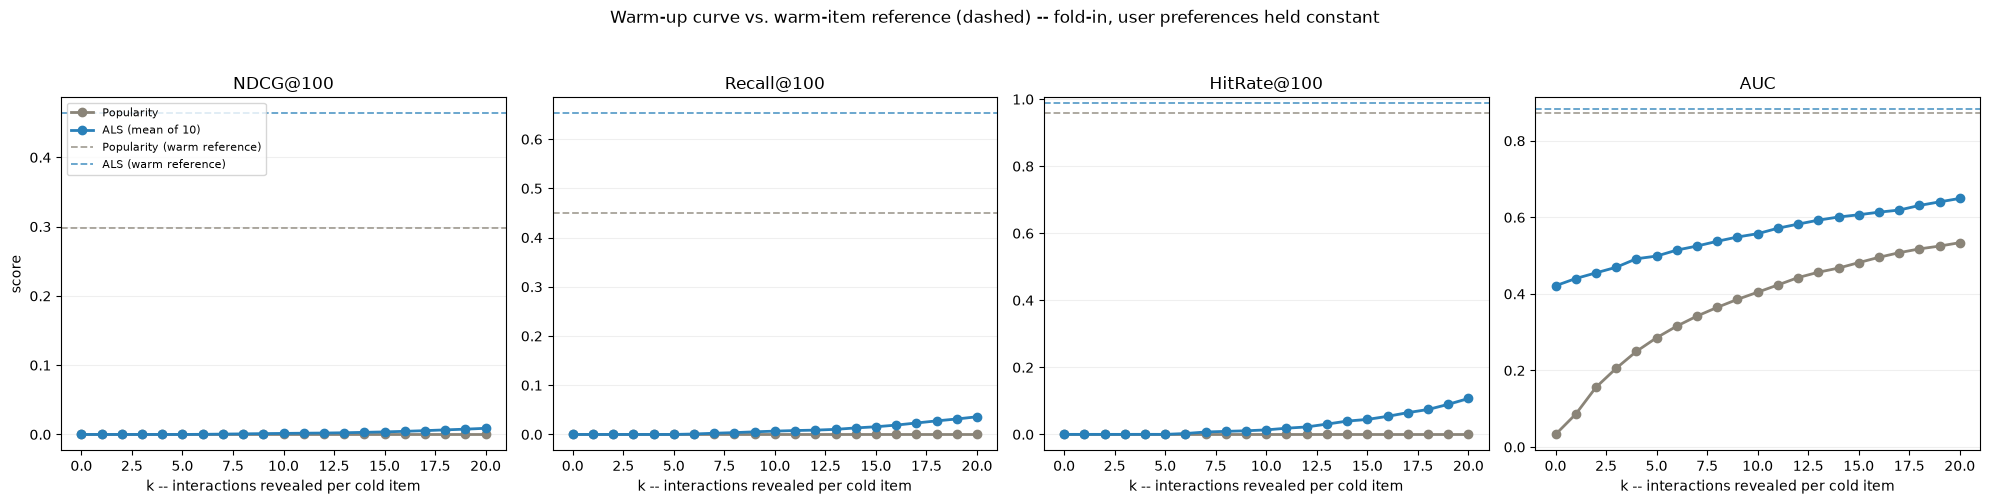

In [13]:
fig, axes = plt.subplots(1, 4, figsize=(20, 4.8), sharex=True)

for i, (ax, metric) in enumerate(zip(axes, METRICS)):
    als_mean = np.array(curve["ALS_mean"][metric])
    als_std = np.array(curve["ALS_std"][metric])
    show_label = (lambda text: text) if i == 0 else (lambda text: None)

    ax.plot(K_LEVELS, curve["Popularity"][metric], marker="o", markersize=6, linewidth=2,
            color="#8A8478", label=show_label("Popularity"))
    ax.plot(K_LEVELS, als_mean, marker="o", markersize=6, linewidth=2,
            color="#2980b9", label=show_label(f"ALS (mean of {N_SEEDS})"))
    ax.fill_between(K_LEVELS, als_mean - als_std, als_mean + als_std, color="#2980b9", alpha=0.15, linewidth=0)
    ax.axhline(reference["Popularity"][metric], color="#8A8478", linestyle="--", linewidth=1.3, alpha=0.75,
               label=show_label("Popularity (warm reference)"))
    ax.axhline(reference["ALS_mean"][metric], color="#2980b9", linestyle="--", linewidth=1.3, alpha=0.75,
               label=show_label("ALS (warm reference)"))

    ax.set_title("AUC" if metric == "AUC" else f"{metric}@{K}")
    ax.set_xlabel("k -- interactions revealed per cold item")
    ax.grid(axis="y", alpha=0.2)

axes[0].set_ylabel("score")
axes[0].legend(fontsize=8, loc="upper left")
fig.suptitle("Warm-up curve vs. warm-item reference (dashed) -- fold-in, user preferences held constant", y=1.04)
plt.tight_layout()
plt.show()

## 10. Warm-up curve — item-to-user view (Mode B)

Section 9 asks, from a *user's* perspective: does this cold item surface in my personal
top-K? This section asks the same question from the opposite direction — the one a
targeted-marketing or "who should we push this item to" use case actually needs: for a single
cold item, rank every user by predicted affinity, and check whether the users who are known
(from the reserved test set) to actually be interested in it land near the top of *its*
top-K.

**Same fold-in factors, transposed ranking axis.** No new fitting happens here. Section 7's
`fold_in_scores(seed_model, k)` already produces the exact item factor needed; the only
difference is that Mode B sorts a score matrix's columns (users, for one item) instead of its
rows (items, for one user). The frozen-user-factor principle governing the rest of this
notebook holds here too — `seed_model.user_factors` is read, never modified.

**Exclusion analog.** Section 9's `filter_already_liked_items` excludes items a user has
already interacted with. Mode B's analog excludes users already in the item's own *revealed*
pool at reveal level `k` — they've already been "reached," so ranking them again would be
circular.

**Why Popularity itself has no line here.** Popularity assigns every user an identical score
for a given item — it has no per-user signal to rank users *by*, only a global item ranking.
Its item-to-user "ranking" is therefore a tie among every remaining user, which carries no
information on its own. But the *principle* behind Popularity — rank by observed volume, no
personalization involved — has a direct dual on this side of the matrix: **global user
activity**. Just as the globally most-popular item is the one a random user is statistically
most likely to have consumed, the globally most-active user is the one statistically most
likely to have consumed a random item, cold ones included. That's the floor used below: every
user's total interaction count in `ref_train` (computed once, frozen — exactly how
`user_factors` are treated everywhere else in this notebook), ranked descending, with the
item's own already-revealed users excluded the same way ALS's ranking excludes them.

**Why `K=10` here, not Section 9's `K=100`.** Mode B's candidate pool is the ~940 remaining
users, not the ~1,600-item catalog — a much smaller pool to begin with — and each cold item
averages roughly 85 reserved test users. At `K=100`, even a fairly weak ranking clears close
to a guaranteed hit against that large a per-item test set, so HitRate@100 saturates near 1.0
and stops discriminating between models. `K=10` keeps that expected hit count modest, which is
also a more realistic size for an actual "who gets the marketing push" campaign than a
100-user list.

**Adding Precision@K.** Recall@K is capped at `K / r_i` for an item with `r_i` reserved test
users — an item with 200 reserved users can't exceed Recall=0.05 even under a perfect model,
a real cross-item comparability problem when `r_i` varies as much as it does across these 87
cold items. Precision@K doesn't fix that, it inverts it: Precision@K is capped at `r_i / K`
for any item with fewer than `K` test users, so a small-`r_i` item can't reach Precision=1.0
either. Both are reported below for what they each measure on their own terms (Recall: how
much of the true audience did we reach; Precision: of who we targeted, how many wanted it) —
neither is asked to solve the cross-item comparability problem, since NDCG@K (normalized by
each item's own `min(r_i, K)` ceiling) already does that correctly.

**Max-possible score, every metric.** `mode_b_ceiling()` reports what a hypothetically
perfect ranking — not ALS's, anyone's — would score on each metric, plotted as a flat dotted
line on every subplot. For NDCG, HitRate, and AUC this ceiling is a trivial, always-1.0 value
(NDCG is self-normalized by IDCG; HitRate needs only one hit, guaranteed whenever `r_i ≥ 1`;
AUC's perfect ranking always places every positive above every negative) — these three don't
have the comparability problem below, so their ceiling carries little information beyond "1.0
is the top of the axis." Precision@K and Recall@K are the two that actually depend on `r_i`:
`min(K, r_i)/K` gives the Precision ceiling, `min(K, r_i)/r_i` gives the Recall ceiling, and on
the (pre-downsampling) full reserved test set these varied a lot across items — an item with
200 reserved users can't exceed Recall=0.05 under a perfect model, and Precision doesn't fix
that, it inverts it. Because `r_i` comes from the fixed reserved test set (or, for
Precision/Recall/NDCG/HitRate below, the fixed Downsampled Test Set — see next paragraph),
every ceiling here is the same at every reveal level `k`. The gap between ALS's curve and its
ceiling at `k=20` is headroom that more revealed history cannot close — it reflects ranking
quality itself, not insufficient data.

**Downsampled Test Set, for the metrics that actually have the comparability problem.**
Precision@K and Recall@K have real `r_i`-dependent ceilings, and `r_i` ranges from 5 to 487
across these 87 items. Averaging those two metrics across items with such different ceilings
conflates "the model underperformed" with "this item's ceiling was always going to be much
lower." The fix: draw a fixed, random 5-user sample from each cold item's reserved test pool
— discarding the rest — for NDCG/Precision/Recall/HitRate. Every eligible item is guaranteed
at least 5 reserved users by construction (`MIN_INTERACTIONS(25) - N_REVEAL(20) = 5`), so
nothing needs to be dropped or padded; 5 is the population's actual guaranteed floor, not an
arbitrary pick. The sample is drawn once, with a fixed seed, and reused identically across
every `k` and every seed model — the same "select once, reuse everywhere" treatment already
applied to the cold-item selection itself (Section 4.1). AUC is left on the full reserved
test set throughout, since its ceiling is trivially 1.0 regardless of `r_i` and it only
benefits from the larger sample.

In [14]:
K_MODE_B = 10  # top-K cutoff for Mode B specifically -- see markdown above for why this differs from K
METRICS_MODE_B = ["NDCG", "Precision", "Recall", "HitRate", "AUC"]

DOWNSAMPLE_SIZE = 5  # the guaranteed minimum reserved test count per eligible item -- see markdown
downsample_rng = np.random.default_rng(42)

downsample_rows, downsample_cols = [], []
_full_test_csc = test_matrix.tocsc()
for item_idx in sorted(reveal_pool.keys()):
    start, end = _full_test_csc.indptr[item_idx], _full_test_csc.indptr[item_idx + 1]
    item_test_users = _full_test_csc.indices[start:end]
    chosen = downsample_rng.choice(item_test_users, size=DOWNSAMPLE_SIZE, replace=False)
    for u in chosen:
        downsample_rows.append(u)
        downsample_cols.append(item_idx)

downsampled_test_matrix = sparse.csr_matrix(
    (np.ones(len(downsample_rows)), (downsample_rows, downsample_cols)),
    shape=(n_users, n_items),
)
print(f"Downsampled test set: {downsampled_test_matrix.nnz:,} interactions across "
      f"{len(reveal_pool)} items ({DOWNSAMPLE_SIZE} per item, exactly).")


def item_to_user_scores(seed_model, k, K=K_MODE_B):
    """Mode B: for each cold item, rank users by predicted affinity (frozen user factors dot
    the item's fold-in factor at reveal level k), excluding users already in the item's
    revealed pool. NDCG/Precision/Recall/HitRate use the Downsampled Test Set (fixed 5 users
    per item, see markdown above); AUC uses the full reserved test set and needs no K at all."""
    item_ids = sorted(reveal_pool.keys())
    factors = fold_in_scores(seed_model, k)  # full item_factors, cold items folded in (Section 7)
    item_vecs = factors[item_ids]
    scores = seed_model.user_factors @ item_vecs.T  # n_users x n_cold

    downsampled_csc = downsampled_test_matrix.tocsc()
    full_csc = test_matrix.tocsc()
    ndcgs, precisions, recalls, hits, aucs = [], [], [], [], []
    for col, item_idx in enumerate(item_ids):
        d_start, d_end = downsampled_csc.indptr[item_idx], downsampled_csc.indptr[item_idx + 1]
        relevant_downsampled = set(downsampled_csc.indices[d_start:d_end].tolist())
        f_start, f_end = full_csc.indptr[item_idx], full_csc.indptr[item_idx + 1]
        relevant_full = set(full_csc.indices[f_start:f_end].tolist())
        if not relevant_downsampled:
            continue
        revealed_users = reveal_pool[item_idx][:k]
        item_scores = scores[:, col].copy()
        item_scores[revealed_users] = -np.inf  # already-reached users can't be "found" again

        ranked_users = np.argsort(-item_scores)[:K]
        ranked_set = set(ranked_users.tolist())
        n_hit = len(relevant_downsampled & ranked_set)
        precisions.append(n_hit / len(ranked_set) if len(ranked_set) else 0.0)
        recalls.append(n_hit / len(relevant_downsampled))
        hits.append(1.0 if n_hit > 0 else 0.0)

        ideal_hits = min(len(relevant_downsampled), K)
        idcg = sum(1.0 / np.log2(r + 2) for r in range(ideal_hits))
        dcg = sum(1.0 / np.log2(r + 2) for r, u in enumerate(ranked_users) if u in relevant_downsampled)
        ndcgs.append(dcg / idcg if idcg > 0 else 0.0)

        if relevant_full:
            candidate_mask = np.ones(n_users, dtype=bool)
            candidate_mask[revealed_users] = False
            candidate_ids = np.flatnonzero(candidate_mask)
            is_positive = np.isin(candidate_ids, list(relevant_full))
            n_pos, n_neg = int(is_positive.sum()), len(candidate_ids) - int(is_positive.sum())
            if n_pos > 0 and n_neg > 0:
                ranks = rankdata(item_scores[candidate_ids])
                rank_sum_pos = ranks[is_positive].sum()
                aucs.append((rank_sum_pos - n_pos * (n_pos + 1) / 2) / (n_pos * n_neg))

    return (float(np.mean(ndcgs)), float(np.mean(precisions)), float(np.mean(recalls)),
            float(np.mean(hits)), float(np.mean(aucs)) if aucs else float("nan"), len(recalls))


# Frozen once, exactly like user_factors: total interaction volume per user in ref_train.
# This is the direct dual of PopularityModel's per-item interaction count (Section 5a) --
# same "rank by observed volume, no personalization" principle, opposite axis.
user_activity = np.asarray((ref_train > 0).sum(axis=1)).ravel()
activity_ranked_users = np.argsort(-user_activity)


def item_to_user_activity_baseline(k, K=K_MODE_B):
    """Global-user-activity floor for Mode B: the same frozen activity ranking is used for
    every cold item (mirroring how PopularityModel uses the same item ranking for every user),
    filtered only by that item's own already-revealed users. NDCG/Precision/Recall/HitRate use
    the Downsampled Test Set; AUC uses the full reserved test set, same split as item_to_user_scores."""
    item_ids = sorted(reveal_pool.keys())
    downsampled_csc = downsampled_test_matrix.tocsc()
    full_csc = test_matrix.tocsc()
    ndcgs, precisions, recalls, hits, aucs = [], [], [], [], []
    for item_idx in item_ids:
        d_start, d_end = downsampled_csc.indptr[item_idx], downsampled_csc.indptr[item_idx + 1]
        relevant_downsampled = set(downsampled_csc.indices[d_start:d_end].tolist())
        f_start, f_end = full_csc.indptr[item_idx], full_csc.indptr[item_idx + 1]
        relevant_full = set(full_csc.indices[f_start:f_end].tolist())
        if not relevant_downsampled:
            continue
        revealed_users = set(reveal_pool[item_idx][:k].tolist())
        picks = [u for u in activity_ranked_users if u not in revealed_users][:K]
        ranked_set = set(picks)
        n_hit = len(relevant_downsampled & ranked_set)
        precisions.append(n_hit / len(picks) if picks else 0.0)
        recalls.append(n_hit / len(relevant_downsampled))
        hits.append(1.0 if n_hit > 0 else 0.0)

        ideal_hits = min(len(relevant_downsampled), K)
        idcg = sum(1.0 / np.log2(r + 2) for r in range(ideal_hits))
        dcg = sum(1.0 / np.log2(r + 2) for r, u in enumerate(picks) if u in relevant_downsampled)
        ndcgs.append(dcg / idcg if idcg > 0 else 0.0)

        if relevant_full:
            candidate_mask = np.ones(n_users, dtype=bool)
            candidate_mask[list(revealed_users)] = False
            candidate_ids = np.flatnonzero(candidate_mask)
            is_positive = np.isin(candidate_ids, list(relevant_full))
            n_pos, n_neg = int(is_positive.sum()), len(candidate_ids) - int(is_positive.sum())
            if n_pos > 0 and n_neg > 0:
                ranks = rankdata(user_activity[candidate_ids])
                rank_sum_pos = ranks[is_positive].sum()
                aucs.append((rank_sum_pos - n_pos * (n_pos + 1) / 2) / (n_pos * n_neg))

    return (float(np.mean(ndcgs)), float(np.mean(precisions)), float(np.mean(recalls)),
            float(np.mean(hits)), float(np.mean(aucs)) if aucs else float("nan"))


def mode_b_ceiling(K=K_MODE_B):
    """Best possible score for every Mode B metric under a hypothetically perfect ranking --
    not ALS's, anyone's. NDCG@K is always ceiling 1.0 by construction (IDCG normalizes against
    the item's own min(r_i, K) achievable DCG, so a perfect ranking always scores 1.0
    regardless of r_i). HitRate@K's ceiling is 1.0 whenever r_i >= 1, which every eligible item
    satisfies by construction. AUC's ceiling is 1.0 (a perfect ranking places every positive
    above every negative) -- computed on the full reserved test set, same population AUC
    itself uses elsewhere in this section, not the Downsampled Test Set. Precision@K and
    Recall@K are the only two that actually depend on r_i: min(K, r_i) is the most true
    positives any top-K list can contain, so dividing by K gives the Precision ceiling and
    dividing by r_i gives the Recall ceiling. On the Downsampled Test Set, r_i is fixed at
    DOWNSAMPLE_SIZE for every item, so these two are now also the same number for every item,
    not just across k."""
    downsampled_csc = downsampled_test_matrix.tocsc()
    max_precisions, max_recalls, max_hitrates = [], [], []
    for item_idx in sorted(reveal_pool.keys()):
        start, end = downsampled_csc.indptr[item_idx], downsampled_csc.indptr[item_idx + 1]
        r_i = end - start
        if r_i == 0:
            continue
        max_precisions.append(min(K, r_i) / K)
        max_recalls.append(min(K, r_i) / r_i)
        max_hitrates.append(1.0 if r_i >= 1 else 0.0)
    return {
        "NDCG": 1.0,
        "Precision": float(np.mean(max_precisions)),
        "Recall": float(np.mean(max_recalls)),
        "HitRate": float(np.mean(max_hitrates)),
        "AUC": 1.0,
    }


mode_b_ceilings = mode_b_ceiling()
print(f"Mode B ceiling at K={K_MODE_B} (perfect ranking, fixed across all k): "
      + "   ".join(f"{m}={mode_b_ceilings[m]:.4f}" for m in METRICS_MODE_B))

mode_b_curve = {"ALS_mean": {m: [] for m in METRICS_MODE_B}, "ALS_std": {m: [] for m in METRICS_MODE_B},
                 "Activity": {m: [] for m in METRICS_MODE_B}}

print("\nItem-to-user (Mode B) sweep:")
for k in K_LEVELS:
    act_ndcg, act_precision, act_recall, act_hit, act_auc = item_to_user_activity_baseline(k)
    for m, v in zip(METRICS_MODE_B, [act_ndcg, act_precision, act_recall, act_hit, act_auc]):
        mode_b_curve["Activity"][m].append(v)

    per_seed = {m: [] for m in METRICS_MODE_B}
    for seed_model in seed_models:
        ndcg, precision, recall, hit, auc, n_eval_items = item_to_user_scores(seed_model, k)
        per_seed["NDCG"].append(ndcg)
        per_seed["Precision"].append(precision)
        per_seed["Recall"].append(recall)
        per_seed["HitRate"].append(hit)
        per_seed["AUC"].append(auc)
    for m in METRICS_MODE_B:
        mode_b_curve["ALS_mean"][m].append(float(np.mean(per_seed[m])))
        mode_b_curve["ALS_std"][m].append(float(np.std(per_seed[m])))

    print(f"k={k:>2}  eval items={n_eval_items:>3}  "
          + "  ".join(f"{m}: ALS={mode_b_curve['ALS_mean'][m][-1]:.4f} "
                       f"Activity={mode_b_curve['Activity'][m][-1]:.4f}" for m in METRICS_MODE_B))

Downsampled test set: 435 interactions across 87 items (5 per item, exactly).
Mode B ceiling at K=10 (perfect ranking, fixed across all k): NDCG=1.0000   Precision=0.5000   Recall=1.0000   HitRate=1.0000   AUC=1.0000

Item-to-user (Mode B) sweep:


k= 0  eval items= 87  NDCG: ALS=0.0082 Activity=0.0681  Precision: ALS=0.0046 Activity=0.0379  Recall: ALS=0.0092 Activity=0.0759  HitRate: ALS=0.0460 Activity=0.2989  AUC: ALS=0.5000 Activity=0.7926
k= 1  eval items= 87  NDCG: ALS=0.0443 Activity=0.0681  Precision: ALS=0.0264 Activity=0.0379  Recall: ALS=0.0529 Activity=0.0759  HitRate: ALS=0.2057 Activity=0.2989  AUC: ALS=0.5701 Activity=0.7930


k= 2  eval items= 87  NDCG: ALS=0.0459 Activity=0.0681  Precision: ALS=0.0266 Activity=0.0379  Recall: ALS=0.0531 Activity=0.0759  HitRate: ALS=0.2379 Activity=0.2989  AUC: ALS=0.5963 Activity=0.7933


k= 3  eval items= 87  NDCG: ALS=0.0394 Activity=0.0682  Precision: ALS=0.0236 Activity=0.0379  Recall: ALS=0.0471 Activity=0.0759  HitRate: ALS=0.2126 Activity=0.2989  AUC: ALS=0.6095 Activity=0.7937


k= 4  eval items= 87  NDCG: ALS=0.0452 Activity=0.0682  Precision: ALS=0.0249 Activity=0.0379  Recall: ALS=0.0499 Activity=0.0759  HitRate: ALS=0.2379 Activity=0.2989  AUC: ALS=0.6287 Activity=0.7940


...

k=16  eval items= 87  NDCG: ALS=0.0629 Activity=0.0689  Precision: ALS=0.0384 Activity=0.0379  Recall: ALS=0.0768 Activity=0.0759  HitRate: ALS=0.3448 Activity=0.2989  AUC: ALS=0.7247 Activity=0.7977


k=17  eval items= 87  NDCG: ALS=0.0615 Activity=0.0704  Precision: ALS=0.0382 Activity=0.0379  Recall: ALS=0.0763 Activity=0.0759  HitRate: ALS=0.3391 Activity=0.2989  AUC: ALS=0.7293 Activity=0.7980


k=18  eval items= 87  NDCG: ALS=0.0661 Activity=0.0706  Precision: ALS=0.0407 Activity=0.0379  Recall: ALS=0.0814 Activity=0.0759  HitRate: ALS=0.3586 Activity=0.2989  AUC: ALS=0.7355 Activity=0.7983


k=19  eval items= 87  NDCG: ALS=0.0692 Activity=0.0707  Precision: ALS=0.0426 Activity=0.0379  Recall: ALS=0.0853 Activity=0.0759  HitRate: ALS=0.3701 Activity=0.2989  AUC: ALS=0.7437 Activity=0.7986


k=20  eval items= 87  NDCG: ALS=0.0722 Activity=0.0707  Precision: ALS=0.0428 Activity=0.0379  Recall: ALS=0.0855 Activity=0.0759  HitRate: ALS=0.3839 Activity=0.2989  AUC: ALS=0.7493 Activity=0.7990


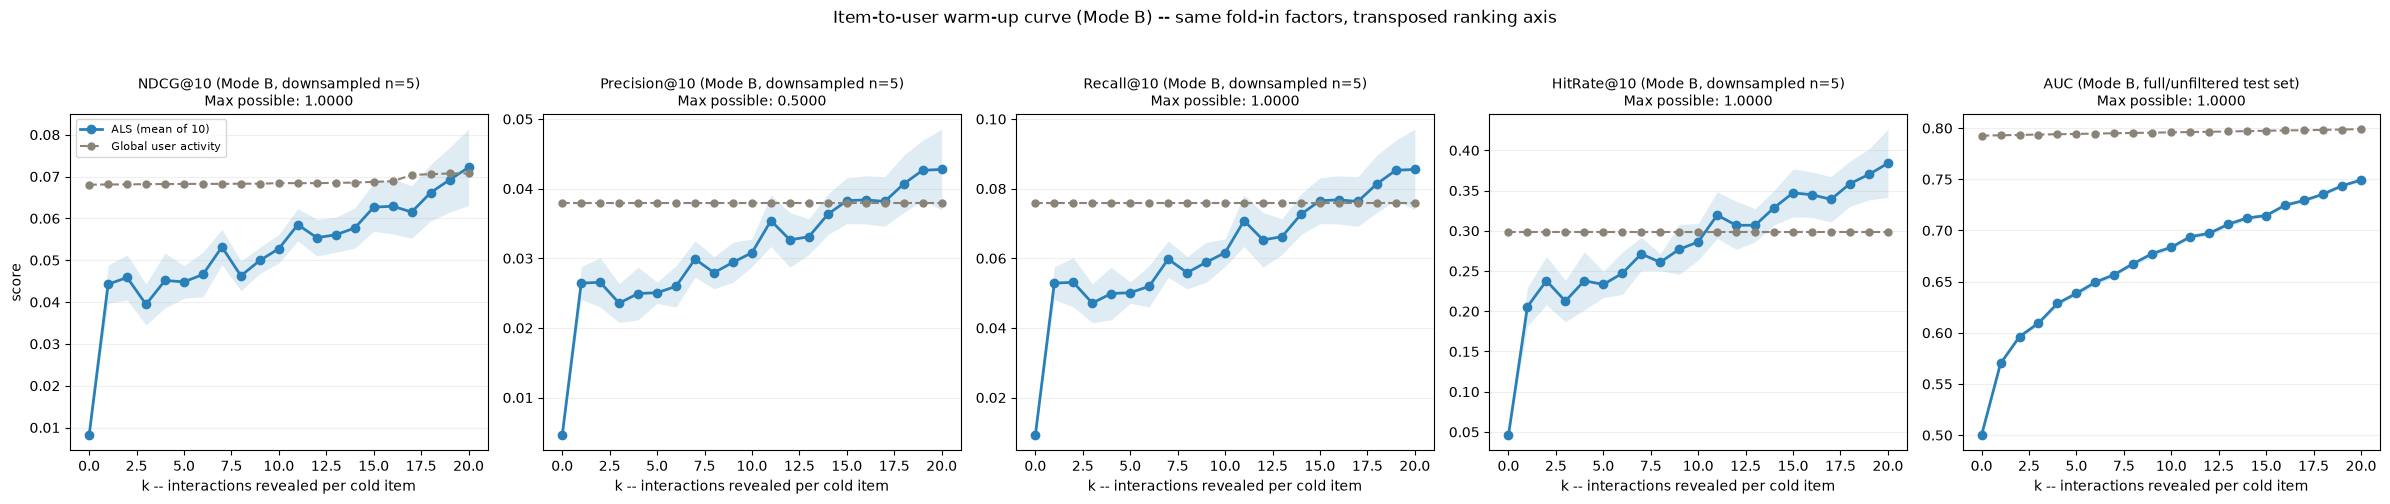

In [15]:
fig, axes = plt.subplots(1, 5, figsize=(24, 4.8), sharex=True)

for i, (ax, metric) in enumerate(zip(axes, METRICS_MODE_B)):
    als_mean = np.array(mode_b_curve["ALS_mean"][metric])
    als_std = np.array(mode_b_curve["ALS_std"][metric])
    show_label = (lambda text: text) if i == 0 else (lambda text: None)

    ax.plot(K_LEVELS, als_mean, marker="o", markersize=6, linewidth=2,
            color="#2980b9", label=show_label(f"ALS (mean of {N_SEEDS})"))
    ax.fill_between(K_LEVELS, als_mean - als_std, als_mean + als_std, color="#2980b9", alpha=0.15, linewidth=0)
    ax.plot(K_LEVELS, mode_b_curve["Activity"][metric], marker="o", markersize=5, linewidth=1.5,
            linestyle="--", color="#8A8478", label=show_label("Global user activity"))

    # Ceiling is noted in the title only, not drawn as a line -- an axhline at (often) 1.0 would
    # force the y-axis to stretch to include it, flattening out real differences between ALS
    # and Activity that only span a few hundredths (e.g. NDCG's ~0.07-0.11 range).

    title_line1 = ("AUC (Mode B, full/unfiltered test set)" if metric == "AUC"
                   else f"{metric}@{K_MODE_B} (Mode B, downsampled n={DOWNSAMPLE_SIZE})")
    ax.set_title(f"{title_line1}\nMax possible: {mode_b_ceilings[metric]:.4f}", fontsize=10)
    ax.set_xlabel("k -- interactions revealed per cold item")
    ax.grid(axis="y", alpha=0.2)

axes[0].set_ylabel("score")
axes[0].legend(fontsize=8, loc="upper left")
fig.suptitle("Item-to-user warm-up curve (Mode B) -- same fold-in factors, transposed ranking axis", y=1.04)
plt.tight_layout()
plt.show()

### Reading the Downsampled Test Set results against AUC's full-set result

The four Downsampled Test Set metrics (NDCG, Precision, Recall, HitRate) and AUC tell
*different* stories here, and that's expected, not a contradiction — they're measured against
different populations on purpose.

On the Downsampled Test Set, **ALS crosses over and overtakes the global-user-activity floor**
on all four metrics somewhere between `k=11` and `k=15`, and the lead keeps growing through
`k=20`: HitRate@10 ends at 0.3839 (ALS) vs. 0.2989 (Activity), NDCG@10 at 0.0722 vs. 0.0707,
Precision@10 at 0.0428 vs. 0.0379, Recall@10 at 0.0855 vs. 0.0759. Once every cold item is
held to the same fixed difficulty (5 test users each), ALS's actual per-item ranking signal
shows through instead of being buried under the handful of high-`r_i`, near-popular items that
dominated the pooled average before.

AUC, still computed on the *full* reserved test set (every `r_i`, 5 to 487, included), keeps
showing ALS trailing Activity through `k=20` (0.7493 vs. 0.7990). That's not inconsistent with
the downsampled result — it isolates *where* the remaining gap lives: concentrated in the
high-`r_i` items specifically (where "target the generally active users" is close to
unbeatable by construction, since so much of the user base already interacted with the item),
not spread evenly across the cold-item population. On a fairness-controlled, per-item basis,
ALS's fold-in ranking is already adding real value by the middle of the reveal sweep; on the
full, blockbuster-inclusive population, it hasn't fully closed the gap by `k=20`.

## 11. Summary

- **Objective:** isolate the effect that a given retrieval method has on how quickly an item
  becomes recommendable as it accumulates interaction history — built so that future
  interventions (content embeddings, improved content embeddings, LLM-simulated interactions)
  can be slotted in and compared against this same baseline on equal footing.
- **The controlling principle:** user preferences are fit once (Section 5b, on `ref_train`)
  and reused identically everywhere in this notebook. Only the item's own representation is
  allowed to vary with reveal level `k`. `recalculate_item` was chosen specifically because
  it performs this exact operation natively — an exact closed-form solve for one item's
  factor, with every user's factor held completely fixed — rather than as an approximation.
- **Cold-item population (Section 4.1):** items with at least 25 total interactions are
  eligible; 10% are selected uniformly at random as cold. Each one's first 20 interactions
  (chronological) are the revealable pool for the `k=0..20` sweep; everything after that is
  permanently reserved for evaluation, unchanged at every `k` — keeping the evaluated
  population perfectly stable across the whole sweep.
- **Reference set (Section 4.2):** a plain random 80/20 split on warm items, evaluated with
  each model's own natively-fit representations — a comparison point, not a warm-up
  experiment. Repeated across the same `N_SEEDS` fits used for the curve.
- **Two methods compared (Section 5):** a no-collaborative-filtering popularity floor (5a)
  and collaborative filtering via ALS (5b) — a fork built to grow, not a fixed pair.
- **Cold-start result (Section 7):** at `k=0`, ALS's item factor is the exact zero vector,
  verified computationally, not merely observed to be small — a stronger, provable version of
  "pure CF cannot recommend a truly unseen item." Popularity's zero is a separate, structural
  guarantee (a zero-count item cannot appear in a popularity ordering).
- **Warm-up curve, user-to-item (Section 9):** built by fold-in, not retraining — the only
  thing that changes between points on the curve is how much of each item's own history has
  been revealed to it.
- **Warm-up curve, item-to-user (Section 10):** the same fold-in factors, ranked along the
  transposed axis — for a cold item, do the right users surface in its top-K? Popularity
  itself has no meaningful version of this (no per-user signal to rank users by), so it's
  compared against its direct dual instead: a frozen global-user-activity ranking, the same
  "rank by observed volume, no personalization" principle applied to the opposite axis. Uses
  its own `K_MODE_B=10` (Section 9's `K=100` would saturate HitRate against this much smaller
  ~940-user candidate pool). NDCG/Precision/Recall/HitRate are computed on a Downsampled Test
  Set (a fixed random 5 test users per cold item, discarding the rest, since every eligible
  item is guaranteed at least 5) so that Precision/Recall's `r_i`-dependent ceilings become
  identical across items instead of conflating "the model underperformed" with "this item's
  ceiling was always lower." AUC keeps the full reserved test set and needs no `K` or ceiling
  at all. The two populations tell different, complementary stories: on the
  fairness-controlled downsampled metrics, ALS overtakes the activity floor by `k≈11–15` and
  keeps widening the lead through `k=20`; on the full-population AUC, ALS still trails the
  activity floor at `k=20`, which localizes the remaining gap to the high-`r_i`,
  near-popular items specifically rather than the cold-item population as a whole.
- **Open, deliberately deferred:** how content embeddings and LLM-simulated interactions
  enter this same fold-in mechanism is not yet designed. Confidence-weighted interactions
  are not used. A cold-user mirror of this experiment (proportional stratification over
  users instead of items) is not yet built.